# Lab 3: Landslide Stability and the Infinite Slope Factor-of-Safety Model
### EES 3350/5350 · Python in Earth Science · Monday, September 14, 2026
> **Due:** Sunday, September 20, at 11:59pm - submit via Brightspace

---

## <span style="color: purple;"> Motivating Geoscience Problem: Landslide Hazard and the Infinite Slope Model <span>
    

Landslides are one of the most important links between hillslopes and the rivers that drain them. Episodic slope failures deliver a huge share of the sediment that ends up in stream channels, shaping fluvial geomorphology and flood behavior downstream. Soil moisture, driven by precipitation and snowmelt, is a primary trigger for many landslides, and changing precipitation patterns are projected to alter how often and how severly hillslopes fail (USGS, 2004, *Landslides Types and Processes*, [Fact Sheet 2004-3072](https://pubs.usgs.gov/fs/2004/3072/fs-2004-3072.html)).
![La Concita](../../course-materials/figures/La-ConchitaLG.jpg)

<span style="font-size:0.85em;color:#6b7a8d;"><em>La conchita, coastal area of southern California. THis landslide and earthflow occured in the spring of 1995. People were ecavuated and the houses nearest ehe slide were completely destroyed. This is a typical type of landslide. Photo by R.L. Schuster, US Geological Survey [USGS Landslide Types and Processes Fact Sheet](https://pubs.usgs.gov/fs/2004/3072/fs-2004-3072.html)</em></span>


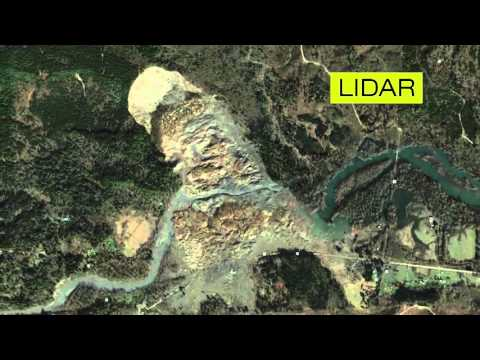

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo('dj44dpr8oHs', width = 800, height=450)

Today, you'll build a Python version of one of the classic tools geologists and engineers use to evaluate hillslope stability: the **infinite slope stability model**, which produces a single number, the **Factor of Safety (FS)**, that compares the forces holding a hillslope together against the forces pulling it downslope.

## The Infinite Slope Stability Model
The **Factor of Safety** is the ratio of resisting forces (what holds the slope together) to destabilizing forces (what pulls it downhill):
$$FS = A + B$$
where:
$$A = \frac{C_r + C_s}{h_s \, \rho_s g \, \sin\theta}$$
$$B = \frac{\cos\theta \, \tan\phi \, \left(1 - \dfrac{R_w \, \rho_w}{\rho_s}\right)}{\sin\theta}$$

and:
| Symbol| Meaning | Units |
|---|---|---|
| $C_r + C_s$ |Cohesion - bonds holding roots (r) and soil (s) together| kg/(m·s$^2$), i.e. Pa|
| $h_s$ | depth of soil perpendicular to the slope | m |
| $\rho_s$ | density of wet soil | kg/m³ |
| $g$ | gravitational acceleration | m/s² |
| $\theta$ | slope angle (angle of the soil surface from horizontal) | degrees |
| $\phi$ | internal friction angle of the soil | degrees |
| $R_w$ | relative wetness - ratio of groundwater depth to soil depth (1 = fully saturated) | dimensionless |
| $\rho_w$ | density of water | kg/m³ |

#### <center>When $FS > 1$, **resisting forces win** and the slope is stable.
#### <center>When $FS < 1$, **gravity wins** and the slope is prone to failure.

Dr. Morey will talk more about Factor of Safety in class this week. If you're itching for more information right now, here's a good link: https://en.wikipedia.org/wiki/Factor_of_safety

---
## Part 1 : Writing the Factor of Safety Function

<div class="alert alert-success">

**Tip**: This equation has a LOT of parts to it. I'd suggest breaking it up into parts, like I've shown you in class. If you need to write something down and work it out on paper first, feel free!
    
</div>

<div class="alert alert-info">

### Exercise 1
Write a function called `factor_of_safety()` that takes the eight parameters of the equation above and returns the FS value.

Things that must be done in the functino:
- convert `slope_deg` and `friction_deg` from degrees to radians before using them in trig functions (`math.radians()`)
- set `gravity = 9.81` and `water_density = 1000` as default values.
    - note: default values must come laste in the list of input parameters. Do you need to rearrange some of those input parameters?
    
</div>

In [ ]:
import math

# your answer here
def factor_of_safety(cohesion, soil_depth, soil_density, gravity, 
                     slope_deg, friction_deg, rw, water_density):
    """
    [fill in a good docstring that explains each input parameter and return]
    """

---
## Part 2 : Testing the Function
Here are three different scenarios, representing low, medium, and high cohesion. Use these three setups to run your function.
| Parameter | Low | Medium | High |
|---|---|---|---|
| Cohesion (Pa) | 0 | 8500 | 17000 |
| Soil depth (m) | 0.2 | 1.0 | 2.5 |
| Soil density (kg/m³) | 2000 | 2000 | 2000 |
| Gravity (m/s²) | 9.81 | 9.81 | 9.81 |
| Slope (degrees) | 5 | 25 | 45 |
| Friction angle (degrees) | 25 | 32 | 40 |
| Relative wetness | 0.0 | 0.5 | 1.0 |
| Water density (kg/m³) | 1000 | 1000 | 1000 |

<div class="alert alert-info">

## Exercise 2
Call `factor_of_safety()` with each of the three scenarios and print the results reasonable rounding.
    
</div>

In [ ]:
# your answer here

### Wait...what would happen if the slope was zero?

<div class="alert alert-info">

## Exercise 3
Call `factor_of_safety()` again using the low cohesion scenario, but set the slope equal to 0. This should produce an error. Basically what's happening is that at $\theta = 0$, $\sin\theta = 0$, which would divide by zero.

Copy and paste your `factor_of_safety()` function in the cell below and handle the slope = 0 edge case. Use `if`/`elif`/`else` so that instead of crashing, the function prints a warning and returns `None` when `slope_deg` ==0.

Call your corrected factor_of_safety() function using the low cohesion scenario again with slope = 0 and confirm that your corrections have worked.
    
</div>

In [ ]:
# your factor_of_safety() function copied and corrected here.

---
## Part 3 : Classifying Stability with `if`/`elif`/`else`
We don't just want to ask whethr FS is above or below 1. A slope closes to 1 is still considered risky. A Common rule of thumb classifies slopes roughly as:
- **FS < 1.0** : Unstable
- **1.0 ≤ FS < 1.3** : Marginally stable
- **FS ≥ 1.3** : Stable

<div class="alert alert-info">

### Exercise 4
Write a function called `interpret_stability(fs)` that takes an FS value and returns one of the three classification strings above using `if`/`elif`/`else`. Then apply it to your three results from Exercise 2.

You do not need a full docstring with Parameters and Returns, but please include a sentence saying what this function does.
    
</div>

In [ ]:
# your answer here

---
## Part 4 : Sensitivity Questions

<div class="alert alert-info">

### Exercise 5
Answer the following using your `factor_of_safety()` function (compute values where needed rather than reasoning purely symbolically).


<div class="alert alert-info">

#### 5.1 What does it mean when FS = 1?
</div>

> your answer here

<div class="alert alert-info">

#### 5.2 What are the units of FS?
Hint: cancel out the units in the equation.
</div>

> your answer here.

<div class="alert alert-info">

#### 5.3 What happens to term A when cohesion is 0?
</div>

In [ ]:
# code cell if you need it

> your answer here

<div class="alert alert-info">

#### 5.4 What is FS when slope is 0?
Can you dvide by 0?
</div>

In [ ]:
# code cell if you need it

> your answer here

<div class="alert alert-info">

#### 5.5 What is FS when soil depth is great (like 30 m) and the soil is fully saturated? Why do you think that is?
Hint: cancel out the units in the equation.
</div>

In [ ]:
# code cell if you need it

> your answer here

<div class="alert alert-info">

#### 5.6 Why do you think the "high" example, despite having the highest cohesion resulted in FS < 1?
</div>

> your answer here

<div class="alert alert-info">

#### 5.7 What parts of this equation are likely to be influenced by climate? How might that depend on location and time of year?
</div>

> your answer here

---
## Part 5 : Graphing FS vs. Slope
Now let's see how FS changes with slope angle under wet vs. dry condiitons, holding the other parameters at the "medium" example values (cohesion = 8500 Pa, soil depth = 1.0, friction angle = 32 deg).

I've made a plotting function for you:

In [ ]:
import matplotlib.pyplot as plt

def plot_fs_vs_slope(slopes, fs_wet, fs_dry):
    """
    """
    plt.plot(slopes, fs_wet, marker="o", label="Rw = 1 (saturated)")
    plt.plot(slopes, fs_dry, marker="o", label="RW=0.1 (dry)")
    plt.axhline(1, color="gray", linestyle="--", label="FS = 1 (threshold)")
    plt.xlabel("Slope angle (degrees)")
    plt.ylabel("Factor of Safety")
    plt.title("Factor of Safety vs. Slope Angle")
    plt.legend()
    plt.show()

<div class="alert alert-info">

## Exercise 6
Build a list of slope values from 0 to 45 degrees in increments of 5 (skip 0, since we know it's undefined from Exercise 4d). For each slope value, compute FS under saturated conditions (Rw=1.0) and dry conditions (Rw=0.1), holding cohesion, soil depth, and friction angle at the "medium" example values.

Then call `plot_fs_vs_slope()` with your results.

**Heads up:** y'all haven't learned loops yet (that starts on Wednesday). This means you will write out one function call per slope value, per condition. I know this is tedius. We will learn loops and this same process will take about 4 lines of code instead of 40. For now though, build the lists by hand.
    
</div>

In [ ]:
# your answer here

<div class="alert alert-info">

### Exercise 7
Answer the following based on your plot.
    
</div>

<div class="alert alert-info">

#### 7.1 How does FS change as slope increases?
</div>

> your answer here

<div class="alert alert-info">

#### 7.2 Is the relationship between slope and FS linear or not?
</div>

> your answer here

<div class="alert alert-info">

#### 7.3 For the same slope, which RW condition has the higher FS? Explain why?
</div>

> your answer here

---
## Part 6 : Sensitivity Analysis
You've now buiklt `factor_of_safety()` and used it a handful of times. The real value of writing a function is that you can call it dozens of times cheaply to ask "what if?" questions. In this part, you'll hold every parameter fixed except one, sweep that one parameter across a realistic range, and see how much it actually matters to stability.

I've provided a small plotting function so you can focus on the parameters.

In [ ]:
def plot_fs_vs_variable(x_values, fs_values, xlabel, title):
    """ 
    Plot Factor of Safety against a single swept variable, with a reference line at FS = 1
    """
    plt.plot(x_values, fs_values, marker="o")
    plt.axhline(1, color="gray", linestyle="--", label="FS = 1 (threshold")
    plt.xlabel(xlabel)
    plt.ylabel("Factor of Safety")
    plt.title(title)
    plt.legend()
    plt.show()

<div class="alert alert-info">

### Exercise 8 : Sensitivity to cohesion

</div>

<div class="alert alert-info">

#### 8.1 : making the plot
Holding the following variables fixed:
- soil depth = 1.0 m,
- friction angle = 32 deg,
- slope = 25 deg,
- Rw = 0.5

Compute FS for cohesion values of:
- 0 Pa
- 4000 Pa
- 8000 Pa
- 12000 Pa
- 16000 Pa
- 20000 Pa

Plot the result with `plot_fs_vs_variable()`

In [ ]:
# your answer here

<div class="alert alert-info">

#### 8.2 : Answer this question.
At cohesion = 0, FS is only just above 1 --essentially a bare-soil slope held up by friction alone. Root cohesion from vegetation is part of what's captured here. Given that, would it be wise to clear all the trees from a hillslope sitting at FS &asymp;1? What part of the equation are you removing when you remove roots?

> your answer here

<div class="alert alert-info">

### Exercise 9 : sensitivity to friction angle
Holding the following variables fixed:
- cohesion = 8500 Pa,
- soil depth = 1.0 m,
- slope = 25 deg,
- Rw = 0.5

Compute FS for internal angle of friction values of:
- 15 deg
- 20 deg
- 25 deg
- 30 deg
- 35 deg
- 40 deg
- 45 deg

Plot the result with `plot_fs_vs_variable()`
</div>

In [ ]:
# your answer here

<div class="alert alert-info">

### Exercise 10 : relative wetness (Rw)
This time, we'll use a more marginal hillslope.

</div>

<div class="alert alert-info">

#### 10.1 : making the plot
Holding the following variables fixed:
- cohesion = 2000 Pa,
- soil depth = 1.0 m,
- slope = 32 deg,
- friction angle = 30 deg,

Compute FS for relative wetness (Rw) values of:
- 0.0
- 0.2
- 0.4
- 0.6
- 0.8
- 1.0

Plot the result with `plot_fs_vs_variable()`

</div>

In [ ]:
# your answer here

<div class="alert alert-info">

#### 10.2 : Answer this question.
This slope is stable when dry. What does the crossing pont on your plot tell you about why landslides so often happen during or right after storms, rather than during dry periods on the exact same hillslope?

> your answer here

<div class="alert alert-info">

### Exercise 11 : sensitivity to soil depth
Holding the following variables fixed:
- cohesion = 8500 Pa,
- slope = 25 deg,
- friction angle = 32 deg,
- Rw = 0.5

Compute FS for soil depths of values of:
- 0.25 m
- 0.5 m
- 1.0 m
- 1.5 m
- 2.0 m
- 3.0 m

Plot the result with `plot_fs_vs_variable()`
</div>

In [ ]:
# your answer here

### The End for Undergraduates!

---
## Part 7 : Graduate Students Only
Every sweep above fixed the slope angle and varied something else. Let's flip that around: for a given set of soil conditions, what is the steepest slope angle that is still stable. In other words, what is the angle where FS crosses exactly 1?

This is a **root-finding problem**: we want the value of `slope_deg` where `factor of safety() - 1 = 0`. Rather than searching by hand, we'll use `scipy.optimize.brentq`, a standard tool for finding roots of a function over an interval. You haven't used `scipy` before--that's the point. Real analysis work constantly means reaching for a well-documented function from an unfamiliar library rather than writing the search algorithm yourself.

#### Explore this method using the following

In [ ]:
from scipy.optimize import brentq

help(brentq)

<div style="background-color:#e8daef; border:1px solid #d2b4de; color:#6c3483; padding:10px; border-radius:4px; margin-bottom:20px;">

### G1.
Using:
- cohesion = 8500 Pa
- soil depth = 1/0 m
- friction angle = 32 deg

find the critical slope angle (the angle at which FS = 1) for both `Rw = 0.1` (dry) and `Rw=1.0` (saturated). `brentq` needs a function of one variable and a bracketing interval known to contain the root (degrees 1 to 89 is a safe bracket here).
    
</div>

In [ ]:
# define a function
def fs_minus_one(slope_deg, rw):
    """
    Calculates FS - 1 as a function of slope angle. For use with brentq.

    In this parameter setup, `slope_deg` will automatically be the variable that
    brentq is trying to figure out. Then, you'll use `arg=(rw)` in your call of brentq
    and it will use that rw value for whatever range you give it.
    """
    # TODO: call factor_of_safety() with the above defined parameters then subtract 1.
    # this function will be the function you input into brentq


# TODO: call brentq() with proper inputs for each. Explore using help(brentq) above. 

<div style="background-color:#e8daef; border:1px solid #d2b4de; color:#6c3483; padding:10px; border-radius:4px; margin-bottom:20px;">

### G2.
The drop in critical angle you just calculated sounds small on paper. In terms of real trrain, what does that mean for how many hillslopes in a given landscape flip from stable to unstable during a major storm, compared to how many were already unstable even when dry?

> your answer here

<div style="background-color:#e8daef; border:1px solid #d2b4de; color:#6c3483; padding:10px; border-radius:4px; margin-bottom:20px;">

### G3. 
You just found the critical slope for a fixed Rw. Now flip it: for a fixed slope angle, find the critical **relative wetness** (the Rw value at which FS crosses 1). Use:
- cohesion = 2000 Pa
- soil depth = 1.0 m
- friction angle = 30 deg
  
and find the critical Rw value for slope angles of:
- 28
- 30
- 32
- 35

In [ ]:
# your answer here

<div style="background-color:#e8daef; border:1px solid #d2b4de; color:#6c3483; padding:10px; border-radius:4px; margin-bottom:20px;">

### G4. A simplified Storm --> Relative Wetness Model

> **IMPORTANT CAVEAT ABOUT THIS SECTION!** Real infiltration physics depends on antecedent soil moisture, hydraulic conductivity, and wetting-front dynamics (see Iverson (2000), Landslide Triggering by Rain Infiltration, Water Resources Research 36:1897–1910, the basis for USGS's TRIGRS model). The function below isa  deliberately simplified "bucket" approximation: net rainfall (intensity minus an assumed steady drainage rate) accumulates in the soil's pore space over the storm's duration. It ignores wetting fronts, antecedent moisture, and everything else that makes real infiltration hard. Treat it as a teaching approximation for building intuition, not a validated hydrological model.

**Using a soil depth of 1/0, porosity of 0.4 (typical for silty/sandy soil), and an assumed drainage riate of 5 mm/hr:**

a. Compute the Rw produced by a 15 mm/hr storm lasting 6 hours. Compare it against your four critical Rw values from G3. Which of those slopes would this storm actually push past failure?

b. Using `brentq` again, find the storm duration (at fixed intensity = 15 mm/hr) needed to reach the critical Rw for the 30 deg slope?

In [ ]:
def storm_to_relative_wetness(intensity_mm_hr, duration_hr, soil_depth, porosity, drainage_rate_mm_hr):
    """
    SIMPLIFIED water-balance approximation of relative wetness from a storm.

    Treats the soil column as a bucket: net rainfall (intensity minus a steady
    drainage rate) accumulates over the storm duration, filling pore space
    from the bottom up. This is NOT a physically rigorous infiltration model
    -- see Iverson (2000) for that. Use for teaching intuition only.

    Parameters
    ----------
    intensity_mm_hr : float -- rainfall intensity (mm/hr)
    duration_hr : float -- storm duration (hr)
    soil_depth : float -- soil depth (m)
    porosity : float -- fraction of soil volume that is pore space (0-1)
    drainage_rate_mm_hr : float -- assumed steady rate water drains away (mm/hr)

    Returns
    -------
    float -- relative wetness (Rw), capped at 1.0 (fully saturated)
    """
    net_rate = intensity_mm_hr - drainage_rate_mm_hr
    if net_rate <= 0:
        return 0.0  # drainage keeps pace with rainfall; no net wetting
    net_input_m = (net_rate * duration_hr) / 1000  # mm -> m
    rise_m = net_input_m / porosity
    return min(1.0, rise_m / soil_depth)

In [ ]:
# your answer here